# Tuition Fee Payment Delay Prediction

Nama    : Vira Annisa

Kelas   : 25 MTTK A

## 1. Business Understanding

Project ini bertujuan untuk membangun model Machine Learning yang dapat memprediksi potensi keterlambatan pembayaran biaya kuliah mahasiswa. Prediksi ini diharapkan dapat membantu institusi melakukan deteksi awal terhadap mahasiswa atau tagihan yang berisiko terlambat, sehingga tindak lanjut seperti pengingat pembayaran, pendampingan, atau rekomendasi bantuan dapat dilakukan lebih cepat.

Target prediksi yang digunakan adalah `is_terlambat`, dengan definisi:
- `0` = pembayaran tepat waktu
- `1` = pembayaran terlambat

Unit observasi pada dataset adalah: `1 row = 1 tagihan pembayaran mahasiswa`

Pada project ini, beberapa model klasifikasi akan dibandingkan untuk mencari model dengan performa terbaik, yaitu:
- Naive Bayes
- Decision Tree
- XGBoost

Model terbaik akan dipilih berdasarkan metrik evaluasi seperti accuracy, precision, recall, F1-score, dan ROC-AUC, kemudian digunakan sebagai dasar implementasi prototype prediksi pada aplikasi Streamlit.

## 2. Import Library

In [55]:
from pathlib import Path
import warnings

# Library untuk manipulasi data dan visualisasi
import joblib # menyimpan model ML
import numpy as np 
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Library untuk preprocesing & Modelling
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer # untuk imputation
from sklearn.metrics import ( # metric evaluasi
    accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
    roc_auc_score,
)
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB # model NB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier # model DT
from xgboost import XGBClassifier # model XGBoost

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')
pd.set_option('display.max_columns', None)
pd.set_option('display.width', 200)


## 3. Load Dataset
Dataset yang digunakan berasal dari file `dataset_v1.csv`. Target yang digunakan adalah `is_terlambat`.

In [56]:
DATA_PATH = Path("dataset_v1.csv")
TARGET_COL = "is_terlambat"

df = pd.read_csv(Path("dataset_v1.csv"), sep=";", 
                 encoding="utf-8-sig", parse_dates=["tanggal_jatuh_tempo"])

df[TARGET_COL] = pd.to_numeric(df[TARGET_COL])

df.head()

,tagihan_id,mahasiswa,tanggal_jatuh_tempo,is_terlambat,nominal_tagihan,nominal_harus_bayar,jenis_pembayaran,tahun_ajaran,semester_tagihan,jenis_semester,bulan_jatuh_tempo,angkatan,kode_prodi,nama_prodi,jalur_masuk,subjalur_masuk,jenis_kelamin,statusmhs_periode,is_statusmhs_periode_missing,kps_status,is_kps_status_missing,jumlah_saudara,is_jumlah_saudara_missing,penghasilan_ortu_label,is_penghasilan_ortu_missing,pendidikan_ayah_label,is_pendidikan_ayah_missing,pendidikan_ibu_label,is_pendidikan_ibu_missing,pekerjaan_ayah,is_pekerjaan_ayah_missing,pekerjaan_ibu,is_pekerjaan_ibu_missing,prev_tagihan_count,prev_late_count,prev_late_ratio,prev_cicilan_count,prev_cicilan_ratio
0,1,Mahasiswa 0001,2014-09-11,0,5200000.0,5200000.0,Semester,2014/2015,5,Ganjil,9,2012,21412,Teknik Mekatronika,PSUD,SMU,L,Aktif,0,Unknown,1,2.0,0,4 Juta,0,S1,0,S1,0,Karyawan Swasta,0,IRT,0,0,0,0.0,0,0.0
1,2,Mahasiswa 0002,2014-09-11,0,5200000.0,5200000.0,Semester,2014/2015,5,Ganjil,9,2012,21412,Teknik Mekatronika,UMPCR,UMPCR I,L,Aktif,0,Unknown,1,3.0,0,1 Juta,0,S2,0,S1,0,PNS,0,Wiraswasta,0,0,0,0.0,0,0.0
2,3,Mahasiswa 0003,2014-09-11,0,5600000.0,5600000.0,Semester,2014/2015,5,Ganjil,9,2012,57301,Sistem Informasi,PSUD,SMU,P,Aktif,0,Unknown,1,2.0,0,4 Juta,0,S2,0,S2,0,PNS,0,PNS,0,0,0,0.0,0,0.0
3,5,Mahasiswa 0005,2014-09-11,0,5200000.0,5200000.0,Semester,2014/2015,5,Ganjil,9,2012,21412,Teknik Mekatronika,UMPCR,UMPCR I,L,Aktif,0,Unknown,1,1.0,0,4 Juta,0,S1,0,SMA,0,Karyawan Swasta,0,IRT,0,0,0,0.0,0,0.0
4,7,Mahasiswa 0007,2014-09-11,0,5600000.0,5600000.0,Semester,2014/2015,5,Ganjil,9,2012,20301,Teknik Elektronika,PSUD,SMU,L,Aktif,0,Unknown,0,3.0,0,Diatas 5 Juta,0,S1,0,SMP,0,Tani,0,IRT,0,0,0,0.0,0,0.0


## 4. Data Understanding

Dataset berisi **9.069 baris** dan **38 kolom**. Kolom yang tersedia mencakup informasi tagihan, periode akademik, program studi, status mahasiswa, data sosial-ekonomi, serta riwayat pembayaran sebelumnya. Terdapat missing value di kolom jumlah_saudara.

In [57]:
print('Shape:', df.shape)
print('Columns:', df.columns.tolist())

print()
print('Data types:')
display(df.dtypes.to_frame('dtype'))

print()
print('Missing values:')
display(df.isna().sum().sort_values(ascending=False).head(20).to_frame('missing_count'))

print()
print('Target distribution:')
display(df[TARGET_COL].value_counts(dropna=False).rename_axis(TARGET_COL).to_frame('count'))

print()
print('Duplicate rows:', df.duplicated().sum())


Shape: (9069, 38)
Columns: ['tagihan_id', 'mahasiswa', 'tanggal_jatuh_tempo', 'is_terlambat', 'nominal_tagihan', 'nominal_harus_bayar', 'jenis_pembayaran', 'tahun_ajaran', 'semester_tagihan', 'jenis_semester', 'bulan_jatuh_tempo', 'angkatan', 'kode_prodi', 'nama_prodi', 'jalur_masuk', 'subjalur_masuk', 'jenis_kelamin', 'statusmhs_periode', 'is_statusmhs_periode_missing', 'kps_status', 'is_kps_status_missing', 'jumlah_saudara', 'is_jumlah_saudara_missing', 'penghasilan_ortu_label', 'is_penghasilan_ortu_missing', 'pendidikan_ayah_label', 'is_pendidikan_ayah_missing', 'pendidikan_ibu_label', 'is_pendidikan_ibu_missing', 'pekerjaan_ayah', 'is_pekerjaan_ayah_missing', 'pekerjaan_ibu', 'is_pekerjaan_ibu_missing', 'prev_tagihan_count', 'prev_late_count', 'prev_late_ratio', 'prev_cicilan_count', 'prev_cicilan_ratio']

Data types:


,dtype
tagihan_id,int64
mahasiswa,str
tanggal_jatuh_tempo,datetime64[us]
is_terlambat,int64
nominal_tagihan,float64
nominal_harus_bayar,float64
jenis_pembayaran,str
tahun_ajaran,str
semester_tagihan,str
jenis_semester,str



Missing values:


,missing_count
jumlah_saudara,5389
tagihan_id,0
tanggal_jatuh_tempo,0
is_terlambat,0
nominal_tagihan,0
mahasiswa,0
nominal_harus_bayar,0
jenis_pembayaran,0
semester_tagihan,0
tahun_ajaran,0



Target distribution:


,count
is_terlambat,
0,8227
1,842



Duplicate rows: 0


## 5. Data Cleaning
Data Cleaning yang dilakukan adalah mengubah jumlah saudara yang negatif menjadi NaN agar bisa diproses pada tahap imputasi dan digunakan untuk modelling.

In [58]:
df = df.copy()

# Jika ada nilai jumlah_saudara negatif, ubah menjadi NaN
# supaya nanti bisa ditangani oleh proses imputasi
df.loc[df["jumlah_saudara"] < 0, "jumlah_saudara"] = np.nan

# Hapus baris yang duplikat, lalu reset index
df = df.drop_duplicates().reset_index(drop=True)

print("Shape setelah cleaning awal:", df.shape)
df.head()

Shape setelah cleaning awal: (9069, 38)


,tagihan_id,mahasiswa,tanggal_jatuh_tempo,is_terlambat,nominal_tagihan,nominal_harus_bayar,jenis_pembayaran,tahun_ajaran,semester_tagihan,jenis_semester,bulan_jatuh_tempo,angkatan,kode_prodi,nama_prodi,jalur_masuk,subjalur_masuk,jenis_kelamin,statusmhs_periode,is_statusmhs_periode_missing,kps_status,is_kps_status_missing,jumlah_saudara,is_jumlah_saudara_missing,penghasilan_ortu_label,is_penghasilan_ortu_missing,pendidikan_ayah_label,is_pendidikan_ayah_missing,pendidikan_ibu_label,is_pendidikan_ibu_missing,pekerjaan_ayah,is_pekerjaan_ayah_missing,pekerjaan_ibu,is_pekerjaan_ibu_missing,prev_tagihan_count,prev_late_count,prev_late_ratio,prev_cicilan_count,prev_cicilan_ratio
0,1,Mahasiswa 0001,2014-09-11,0,5200000.0,5200000.0,Semester,2014/2015,5,Ganjil,9,2012,21412,Teknik Mekatronika,PSUD,SMU,L,Aktif,0,Unknown,1,2.0,0,4 Juta,0,S1,0,S1,0,Karyawan Swasta,0,IRT,0,0,0,0.0,0,0.0
1,2,Mahasiswa 0002,2014-09-11,0,5200000.0,5200000.0,Semester,2014/2015,5,Ganjil,9,2012,21412,Teknik Mekatronika,UMPCR,UMPCR I,L,Aktif,0,Unknown,1,3.0,0,1 Juta,0,S2,0,S1,0,PNS,0,Wiraswasta,0,0,0,0.0,0,0.0
2,3,Mahasiswa 0003,2014-09-11,0,5600000.0,5600000.0,Semester,2014/2015,5,Ganjil,9,2012,57301,Sistem Informasi,PSUD,SMU,P,Aktif,0,Unknown,1,2.0,0,4 Juta,0,S2,0,S2,0,PNS,0,PNS,0,0,0,0.0,0,0.0
3,5,Mahasiswa 0005,2014-09-11,0,5200000.0,5200000.0,Semester,2014/2015,5,Ganjil,9,2012,21412,Teknik Mekatronika,UMPCR,UMPCR I,L,Aktif,0,Unknown,1,1.0,0,4 Juta,0,S1,0,SMA,0,Karyawan Swasta,0,IRT,0,0,0,0.0,0,0.0
4,7,Mahasiswa 0007,2014-09-11,0,5600000.0,5600000.0,Semester,2014/2015,5,Ganjil,9,2012,20301,Teknik Elektronika,PSUD,SMU,L,Aktif,0,Unknown,0,3.0,0,Diatas 5 Juta,0,S1,0,SMP,0,Tani,0,IRT,0,0,0,0.0,0,0.0


## 6. Exploratory Data Analysis
EDA yang dilakukan adalah:
- Distribusi target pembayaran
- Analisis jenis pembayaran
- Statistik fitur numerik
- Analisis fitur kategorikal
- Boxplot fitur numerik
- Correlation heatmap

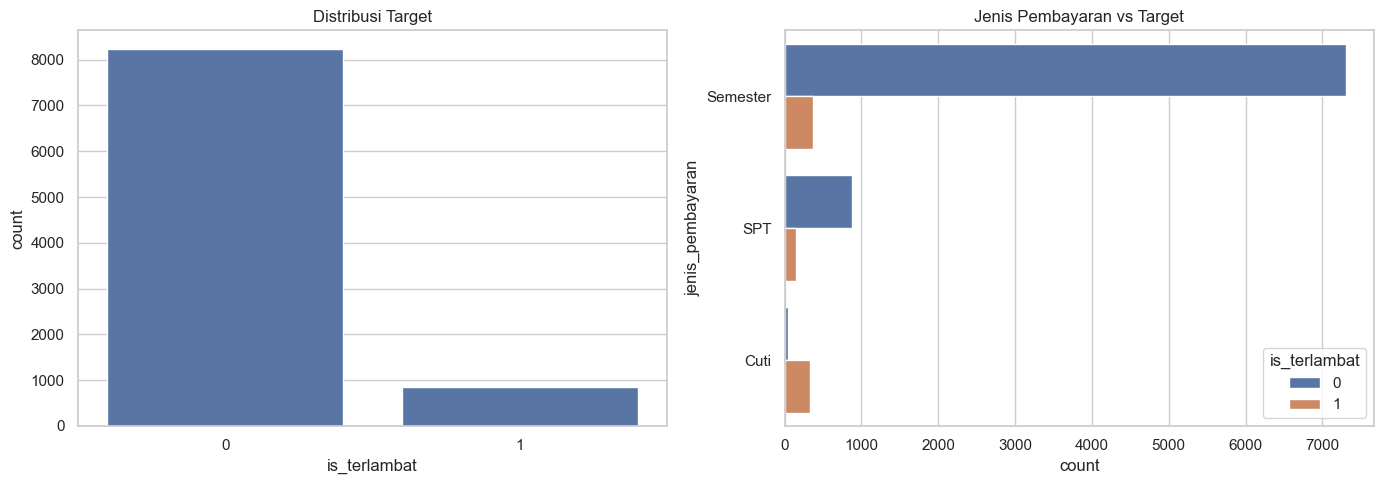

In [59]:
# 1. Distribusi Target dan Jenis Pembayaran

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Tampilkan distribusi target
sns.countplot(data=df, x=TARGET_COL, ax=axes[0])
axes[0].set_title("Distribusi Target")
axes[0].set_xlabel("is_terlambat")

# Tampilkan hubungan jenis pembayaran dengan target 
top_payment = df["jenis_pembayaran"].value_counts().index
sns.countplot(
    data=df[df["jenis_pembayaran"].isin(top_payment)],
    y="jenis_pembayaran",
    hue=TARGET_COL,
    ax=axes[1]
)

axes[1].set_title("Jenis Pembayaran vs Target")
axes[1].set_ylabel("jenis_pembayaran")

plt.tight_layout()
plt.show()

# Hasil: dataset imbalanced karena jumlah pembayaran tepat waktu lebih besar dibandingkan terlambat

Hasil: dataset imbalanced karena jumlah pembayaran tepat waktu lebih besar dibandingkan terlambat.

In [60]:
# Ringkasan Statistik Fitur Numerik

numeric_preview = [
    col for col in [
        'nominal_tagihan',
        'nominal_harus_bayar',
        'prev_tagihan_count',
        'prev_late_count',
        'prev_late_ratio',
        'prev_cicilan_count',
        'prev_cicilan_ratio',
        'jumlah_saudara',
    ]
    if col in df.columns
]

if numeric_preview:
    display(df[numeric_preview].describe().T)


,count,mean,std,min,25%,50%,75%,max
nominal_tagihan,9069.0,5.014128e+06,1.774498e+06,50000.0,5200000.0,5500000.0,6400000.0,15000000.0
nominal_harus_bayar,9069.0,5.592483e+06,1.250734e+06,100000.0,5400000.0,5600000.0,6400000.0,15000000.0
prev_tagihan_count,9069.0,2.445915e+00,2.274713e+00,0.0,1.0,2.0,4.0,19.0
prev_late_count,9069.0,1.114787e-01,5.694292e-01,0.0,0.0,0.0,0.0,12.0
prev_late_ratio,9069.0,7.308748e-02,7.437669e-01,0.0,0.0,0.0,0.0,10.0
prev_cicilan_count,9069.0,3.972875e-01,1.035943e+00,0.0,0.0,0.0,0.0,11.0
prev_cicilan_ratio,9069.0,4.918007e-01,2.010337e+00,0.0,0.0,0.0,0.0,10.0
jumlah_saudara,3680.0,2.932609e+00,1.461036e+00,0.0,2.0,3.0,4.0,12.0


Hasil: Fitur riwayat seperti `prev_late_count`, `prev_late_ratio`, dan `prev_cicilan_count` penting karena dapat menggambarkan pola pembayaran mahasiswa sebelum tagihan yang sedang diprediksi.

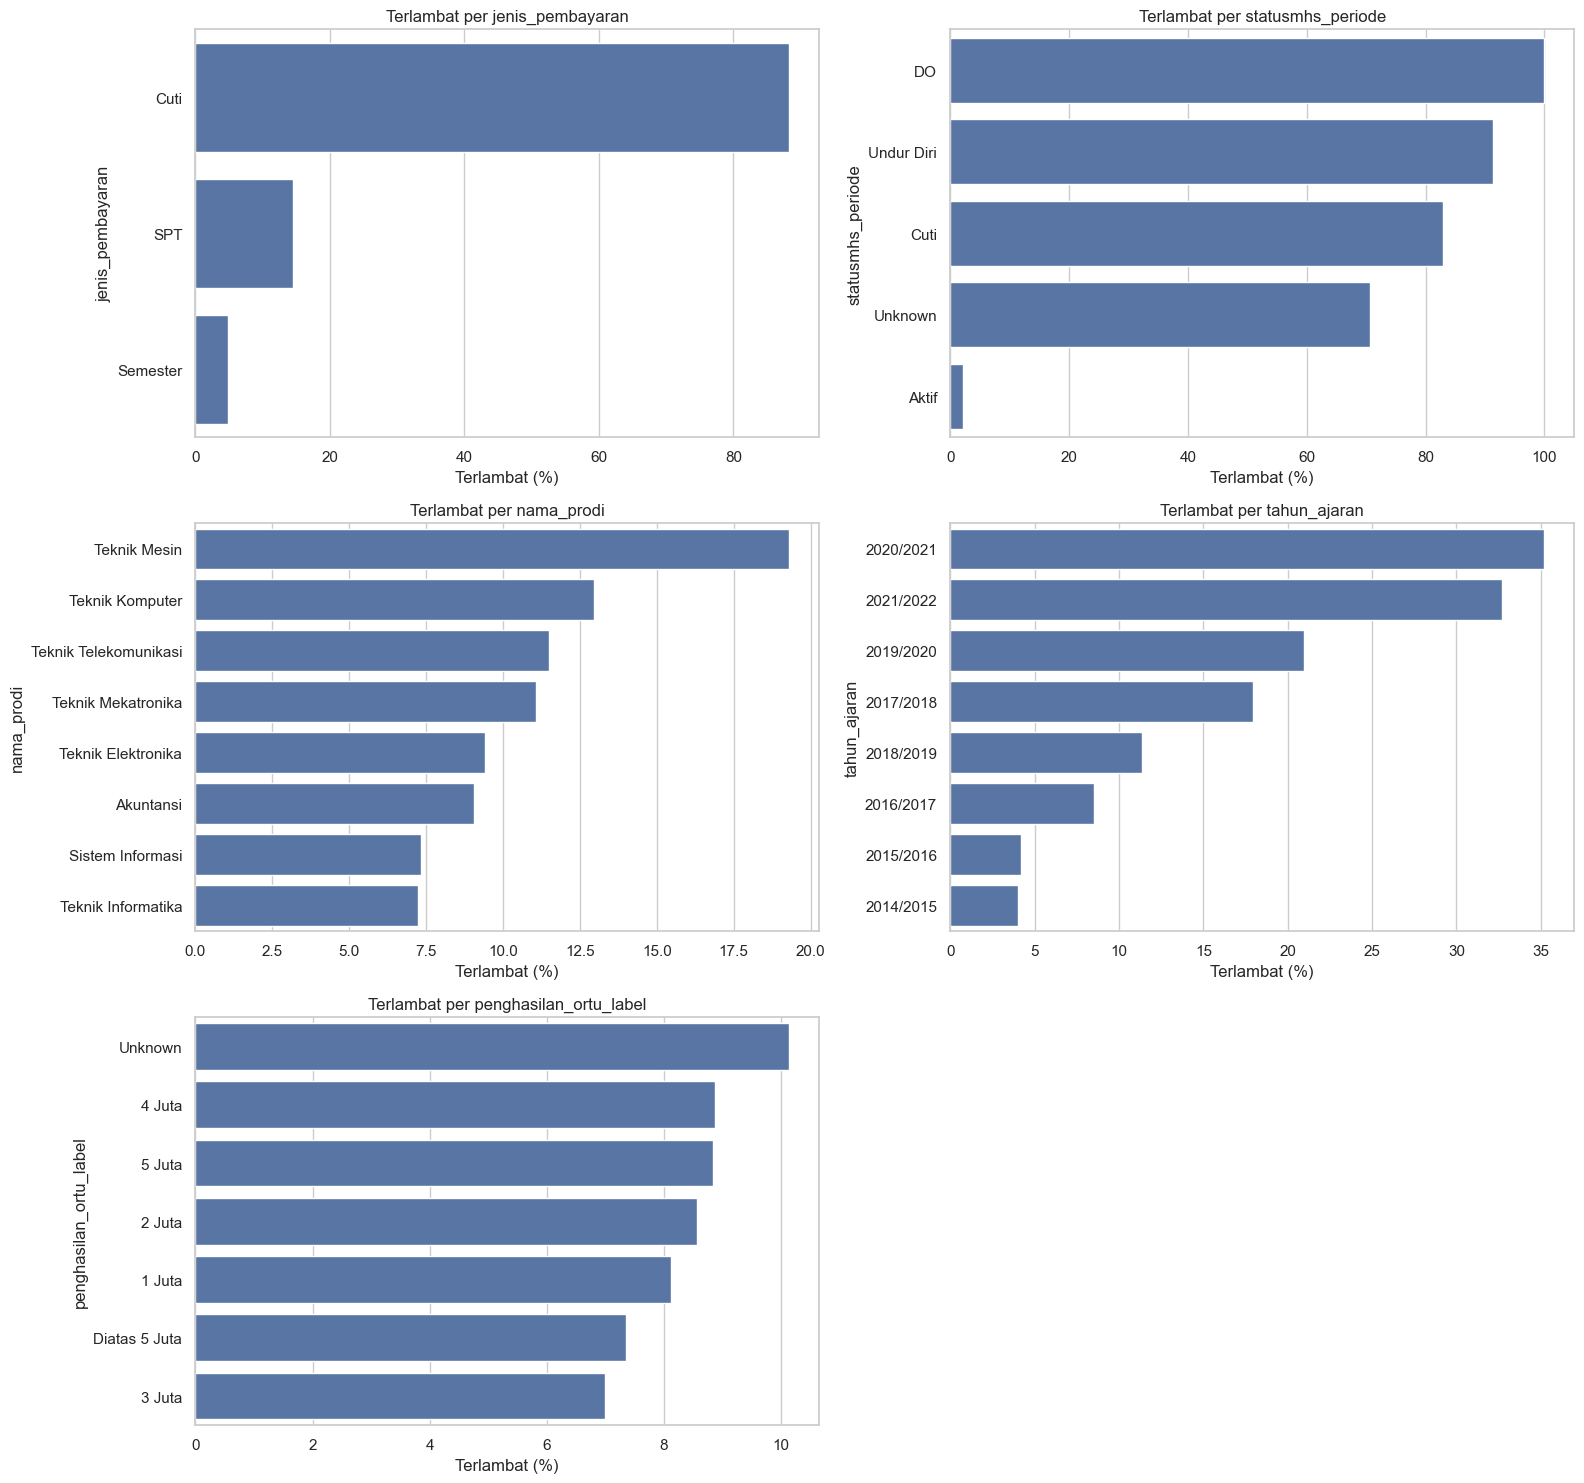

In [61]:
# 3. Persentase Terlambat per Kategori

# Fitur kategorikal yang akan dianalisis
cat_cols = [
    "jenis_pembayaran",
    "statusmhs_periode",
    "nama_prodi",
    "tahun_ajaran",
    "penghasilan_ortu_label",
]

# Ambil hanya kolom yang ada di dataframe
cat_cols = [col for col in cat_cols if col in df.columns]

if cat_cols:
    n_cols = 2
    n_rows = int(np.ceil(len(cat_cols) / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
    axes = np.ravel(axes)

    for ax, col in zip(axes, cat_cols):
        # Ambil 8 kategori paling sering muncul
        top = df[col].value_counts().head(8).index

        # Hitung persentase terlambat per kategori
        plot_df = (
            df[df[col].isin(top)]
            .groupby(col, dropna=False)[TARGET_COL]
            .mean()
            .mul(100)
            .reset_index(name="late_pct")
            .sort_values("late_pct", ascending=False)
        )

        # Plot hasilnya
        sns.barplot(data=plot_df, x="late_pct", y=col, ax=ax)
        ax.set_title(f"Terlambat per {col}")
        ax.set_xlabel("Terlambat (%)")
        ax.set_ylabel(col)

    # Sembunyikan plot kosong
    for ax in axes[len(cat_cols):]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()

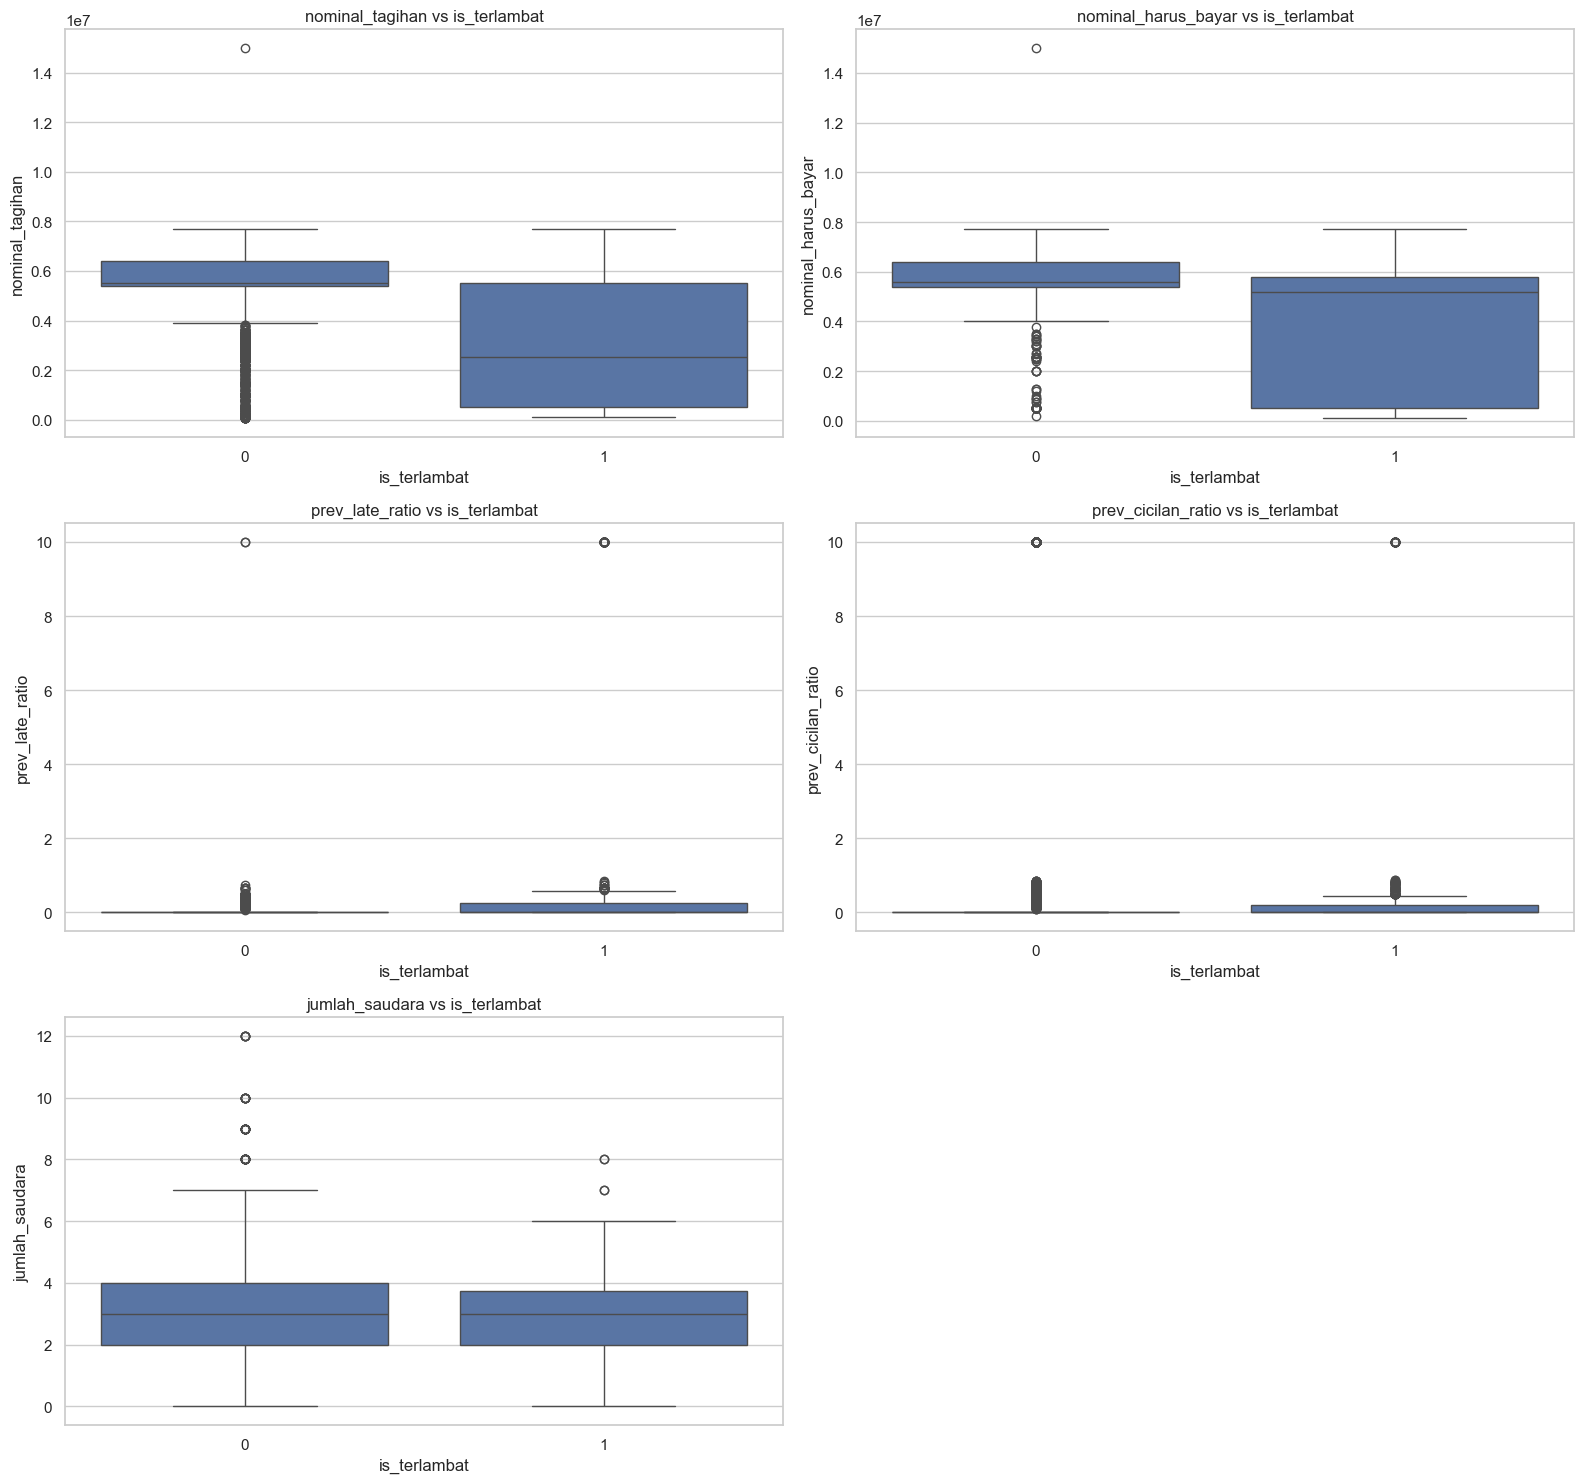

In [62]:
# 4. Boxplot Distribusi Fitur Numerik Berdasarkan Target

# Fitur numerik yang mau dicek
num_cols = [
    "nominal_tagihan",
    "nominal_harus_bayar",
    "prev_late_ratio",
    "prev_cicilan_ratio",
    "jumlah_saudara",
]

# Ambil hanya kolom yang ada di dataframe
num_cols = [col for col in num_cols if col in df.columns]

if num_cols:
    n_cols = 2
    n_rows = int(np.ceil(len(num_cols) / n_cols))

    fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 5 * n_rows))
    axes = np.ravel(axes)

    for ax, col in zip(axes, num_cols):
        # Bandingkan distribusi fitur numerik berdasarkan target
        sns.boxplot(data=df, x=TARGET_COL, y=col, ax=ax)
        ax.set_title(f"{col} vs {TARGET_COL}")
        ax.set_xlabel("is_terlambat")
        ax.set_ylabel(col)

    # Sembunyikan plot kosong
    for ax in axes[len(num_cols):]:
        ax.set_visible(False)

    plt.tight_layout()
    plt.show()

Hasil: Visualisasi fitur numerik memperlihatkan sebaran nilai dan kemungkinan perbedaan pola antara tagihan tepat waktu dan terlambat. Beberapa fitur riwayat pembayaran terlihat relevan karena berkaitan langsung dengan pengalaman keterlambatan sebelumnya.

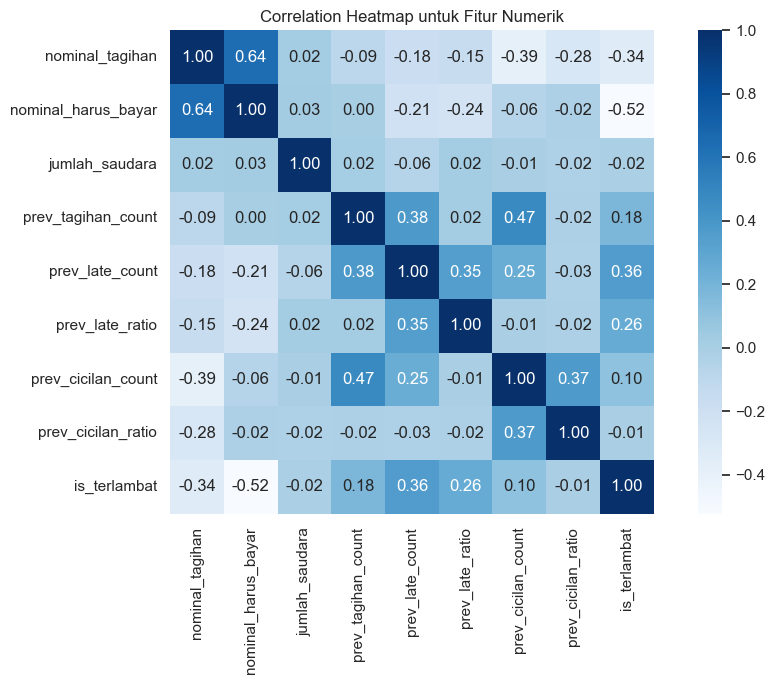

In [63]:
## 5. Correlation Heatmap Fitur Numerik

# Kolom numerik untuk correlation heatmap
corr_cols = [
    "nominal_tagihan",
    "nominal_harus_bayar",
    "jumlah_saudara",
    "prev_tagihan_count",
    "prev_late_count",
    "prev_late_ratio",
    "prev_cicilan_count",
    "prev_cicilan_ratio",
    TARGET_COL,
]

# Ambil hanya kolom yang ada di dataframe
corr_cols = [col for col in corr_cols if col in df.columns]

# Buat heatmap jika kolom cukup untuk dihitung korelasinya
if len(corr_cols) >= 2:
    corr = df[corr_cols].corr(numeric_only=True)

    plt.figure(figsize=(10, 7))
    sns.heatmap(corr, annot=True, fmt=".2f", cmap="Blues", square=True)
    plt.title("Correlation Heatmap untuk Fitur Numerik")
    plt.tight_layout()
    plt.show()

Hasil: Korelasi numerik menunjukkan hubungan antarfitur numerik dan target. Nilai korelasi tidak harus sangat tinggi karena model yang digunakan yaitu XGBoost mampu menangkap pola non-linear dan kombinasi fitur yang lebih kompleks.

## 7. Train-Test Split
Data dibagi menggunakan pendekatan berbasis waktu, yaitu data lama sebagai train dan data yang lebih baru sebagai test untuk membuat model seolah-olah dilatih dari data historis untuk memprediksi periode berikutnya. Pembagiannya adalah 80:20.

In [64]:
# Split data berdasarkan waktu jika kolom tanggal tersedia
if 'tanggal_jatuh_tempo' in df.columns and df['tanggal_jatuh_tempo'].notna().any():

    df = df.sort_values('tanggal_jatuh_tempo').reset_index(drop=True)
    split_index = int(len(df) * 0.8)
    train_df = df.iloc[:split_index].copy()
    test_df = df.iloc[split_index:].copy()
    
else:
    # Jika tidak ada kolom tanggal, gunakan random split
    train_df, test_df = train_test_split(
        df,
        test_size=0.2,
        random_state=42,
        stratify=df[TARGET_COL]
    )

# Cek ukuran data train dan test
print('Train shape:', train_df.shape)
print('Test shape :', test_df.shape)

# Cek distribusi target pada data train
display(train_df[TARGET_COL].value_counts(normalize=True).sort_index().to_frame("ratio"))

# Cek distribusi target pada data test
display(test_df[TARGET_COL].value_counts(normalize=True).sort_index().to_frame("ratio"))


Train shape: (7255, 38)
Test shape : (1814, 38)


,ratio
is_terlambat,
0,0.927498
1,0.072502


,ratio
is_terlambat,
0,0.825799
1,0.174201


## 8. Feature Selection
Seleksi fitur yang tidak digunakan seperti kolom ID, identitas mahasiswa dan tanggal jatuh tempo yang membuat data leakage. 

In [ ]:
# Kolom yang tidak dipakai sebagai fitur
drop_cols = ["tagihan_id", "mahasiswa", "tanggal_jatuh_tempo", 
             "bulan_jatuh_tempo", "jenis_semester", "angkatan", 
             "jalur_masuk", "jenis_kelamin"]

# Kolom flag missing yang tidak dipakai
missing_cols = [col for col in train_df.columns if col.endswith("_missing")]

# Ambil kolom fitur
feature_cols = [col for col in train_df.columns 
                if col not in drop_cols + missing_cols + [TARGET_COL]]

# Pisahkan fitur dan target
X_train = train_df[feature_cols].copy()
y_train = train_df[TARGET_COL].copy()

X_test = test_df[feature_cols].copy()
y_test = test_df[TARGET_COL].copy()

# Pisahkan fitur numerik dan kategorikal
num_cols = X_train.select_dtypes(include=["number", "bool"]).columns.tolist()
cat_cols = [col for col in X_train.columns if col not in num_cols]

num_df = pd.DataFrame({"Nama Fitur": num_cols, "Jenis Fitur": "Numerik"})
cat_df = pd.DataFrame({"Nama Fitur": cat_cols, "Jenis Fitur": "Kategorikal"})

# Cek hasil pemilihan fitur
feature_table = pd.concat([num_df, cat_df], ignore_index=True)
feature_table

# # Cek hasil pemilihan fitur
# print("Jumlah feature:", len(feature_cols))
# print("Numeric features:", num_cols)
# print("Categorical features:", cat_cols)

,Nama Fitur,Jenis Fitur
0,nominal_tagihan,Numerik
1,nominal_harus_bayar,Numerik
2,kode_prodi,Numerik
3,jumlah_saudara,Numerik
4,prev_tagihan_count,Numerik
5,prev_late_count,Numerik
6,prev_late_ratio,Numerik
7,prev_cicilan_count,Numerik
8,prev_cicilan_ratio,Numerik
9,jenis_pembayaran,Kategorikal


## 9. Preprocessing

Tahap preprocessing memisahkan fitur numerik dan kategorikal. 
- Fitur numerik ditangani dengan imputasi dan scaling.
- Fitur kategorikal diubah menggunakan one-hot encoding agar dapat diproses oleh model machine learning.

In [66]:
# Preprocessing:  missing value diisi dengan median
num_pipe = Pipeline([("imputer", SimpleImputer(strategy="median"))])

# Preprocessing untuk fitur kategorikal:
# missing value diisi nilai paling sering, lalu diubah jadi one-hot encoding
cat_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore", sparse_output=False))
])

# Gabungkan preprocessing numerik dan kategorikal
preprocessor = ColumnTransformer([
    ("num", num_pipe, num_cols),
    ("cat", cat_pipe, cat_cols),
])

## 10. Modeling

Tiga model yang dibandingkan adalah:
- `Naive Bayes` untuk baseline sederhana
- `Decision Tree` untuk model yg mudah diinterpretasi
- `XGBoost` yang dapat menangkap pola linerar

Dilakukan scale_pos_weight di XGBoost dan class_weight di DT karena datasetnya imbalanced. 

In [67]:
# Hitung rasio kelas untuk membantu XGBoost menangani data imbalance
positive_count = int((y_train == 1).sum())
negative_count = int((y_train == 0).sum())
scale_pos_weight = negative_count / positive_count if positive_count > 0 else 1.0

# model yang akan dibandingkan

models = {
    'Naive Bayes': GaussianNB(),
    'Decision Tree': DecisionTreeClassifier(
        random_state=42,
        max_depth=6,
        min_samples_split=20,
        class_weight='balanced'
    ),
    "XGBoost": XGBClassifier(
        random_state=42,
        n_estimators=200,
        max_depth=5,
        learning_rate=0.05,
        subsample=0.9,
        colsample_bytree=0.9,
        eval_metric='logloss',
        scale_pos_weight=scale_pos_weight
    ),
}

models


{'Naive Bayes': GaussianNB(),
 'Decision Tree': DecisionTreeClassifier(class_weight='balanced', max_depth=6,
                        min_samples_split=20, random_state=42),
 'XGBoost': XGBClassifier(base_score=None, booster=None, callbacks=None,
               colsample_bylevel=None, colsample_bynode=None,
               colsample_bytree=0.9, device=None, early_stopping_rounds=None,
               enable_categorical=False, eval_metric='logloss',
               feature_types=None, feature_weights=None, gamma=None,
               grow_policy=None, importance_type=None,
               interaction_constraints=None, learning_rate=0.05, max_bin=None,
               max_cat_threshold=None, max_cat_to_onehot=None,
               max_delta_step=None, max_depth=5, max_leaves=None,
               min_child_weight=None, missing=nan, monotone_constraints=None,
               multi_strategy=None, n_estimators=200, n_jobs=None,
               num_parallel_tree=None, ...)}

## 11. Model Evaluation

Evaluasi dilakukan menggunakan:
- Classification report
- Confusion matrix 
- ROC-AUC

Karena target terlambat jumlahnya lebih sedikit, metrik recall dan F1-score untuk kelas `1` penting untuk melihat kemampuan model mendeteksi kasus keterlambatan.

In [68]:
# Fungsi untuk training dan evaluasi model
def evaluate_model(name, model):
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    # Train model
    pipe.fit(X_train, y_train)

    # Prediksi label dan probabilitas
    pred = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]

    # Simpan hasil evaluasi utama
    score = {
        "model": name,
        "accuracy": accuracy_score(y_test, pred),
        "precision": precision_score(y_test, pred, zero_division=0),
        "recall": recall_score(y_test, pred, zero_division=0),
        "f1": f1_score(y_test, pred, zero_division=0),
        "roc_auc": roc_auc_score(y_test, proba),
    }

    return pipe, pred, proba, score


# Tempat menyimpan hasil training dan evaluasi
trained = {}
scores = []
conf_matrices = {}
class_reports = {}

# Training dan evaluasi semua model
for name, model in models.items():
    pipe, pred, proba, score = evaluate_model(name, model)

    trained[name] = pipe
    scores.append(score)
    conf_matrices[name] = confusion_matrix(y_test, pred)
    class_reports[name] = pd.DataFrame(
        classification_report(
            y_test,
            pred,
            digits=4,
            output_dict=True,
            zero_division=0
        )
    ).T

    print(f"===== {name} =====")
    print(classification_report(y_test, pred, digits=4, zero_division=0))
    print("Confusion matrix:")
    print(conf_matrices[name])
    print()

===== Naive Bayes =====
              precision    recall  f1-score   support

           0     0.8499    0.9486    0.8965      1498
           1     0.4577    0.2057    0.2838       316

    accuracy                         0.8192      1814
   macro avg     0.6538    0.5771    0.5902      1814
weighted avg     0.7816    0.8192    0.7898      1814

Confusion matrix:
[[1421   77]
 [ 251   65]]

===== Decision Tree =====
              precision    recall  f1-score   support

           0     0.9511    0.9479    0.9495      1498
           1     0.7570    0.7690    0.7630       316

    accuracy                         0.9168      1814
   macro avg     0.8541    0.8585    0.8562      1814
weighted avg     0.9173    0.9168    0.9170      1814

Confusion matrix:
[[1420   78]
 [  73  243]]

===== XGBoost =====
              precision    recall  f1-score   support

           0     0.9585    0.9559    0.9572      1498
           1     0.7937    0.8038    0.7987       316

    accuracy        

## 12. Model Comparison

- `XGBoost` menjadi model terbaik karena memperoleh nilai tertinggi pada accuracy, precision, recall, F1-score, dan ROC-AUC. 
- Nilai recall dan F1-score yang baik menunjukkan model cukup mampu mendeteksi pembayaran terlambat.
- Sedangkan ROC-AUC yang tinggi menunjukkan kemampuan pemisahan kelas yang baik.

In [69]:
# Buat tabel perbandingan performa model
comparison_df = (
    pd.DataFrame(scores)
    .sort_values(["f1", "recall", "roc_auc"], ascending=False)
    .reset_index(drop=True)
)

display(comparison_df)

# Ambil model terbaik berdasarkan ranking metrik
best_model_name = comparison_df.loc[0, "model"]
best_model = trained[best_model_name]

print("Best model:", best_model_name)

,model,accuracy,precision,recall,f1,roc_auc
0,XGBoost,0.929438,0.793750,0.803797,0.798742,0.951964
1,Decision Tree,0.916759,0.757009,0.768987,0.762951,0.828653
2,Naive Bayes,0.819184,0.457746,0.205696,0.283843,0.702428


Best model: XGBoost


## 13. Feature Importance

- Feature importance menunjukkan bahwa fitur seperti `statusmhs_periode`, `jenis_pembayaran`, `penghasilan_ortu`, dan `riwayat keterlambatan` memiliki kontribusi besar terhadap prediksi. 
- Nilai importance menunjukkan kontribusi fitur terhadap model, tetapi tidak selalu berarti hubungan sebab-akibat secara langsung.

===== XGBoost =====


,feature_group,importance
18,statusmhs_periode,0.454198
17,semester_tagihan,0.064817
4,nama_prodi,0.047737
7,pekerjaan_ayah,0.047507
20,tahun_ajaran,0.047046
11,penghasilan_ortu_label,0.044547
19,subjalur_masuk,0.042034
0,jenis_pembayaran,0.032220
5,nominal_harus_bayar,0.029506
8,pekerjaan_ibu,0.025993


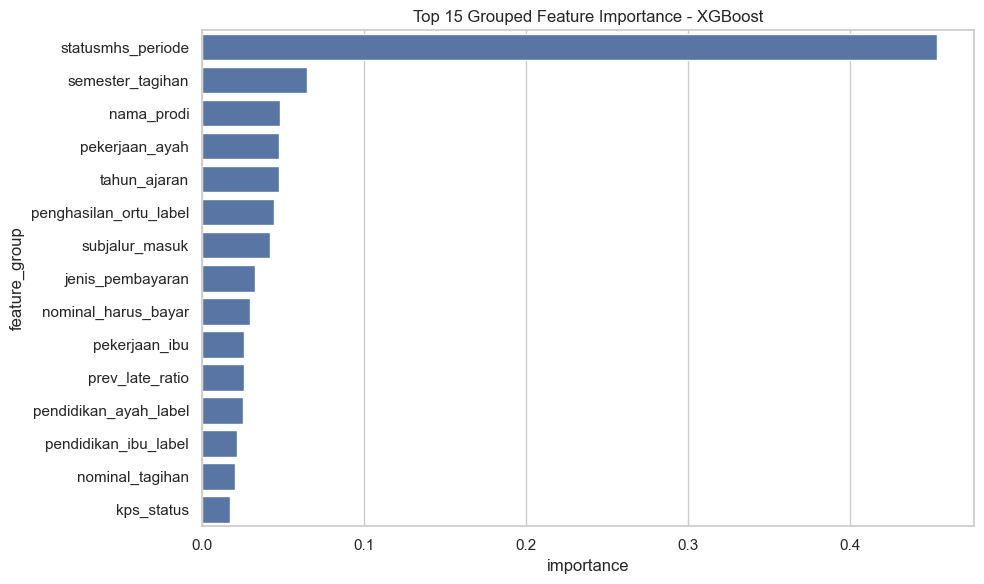

In [70]:
model_name = best_model_name
top_n = 15
feature_importance_results = {}

pipeline = trained[model_name]
model = pipeline.named_steps["model"]
preprocessor = pipeline.named_steps["preprocessor"]

# Ambil nama fitur setelah preprocessing
feature_names = preprocessor.get_feature_names_out()

# Bersihkan prefix dari ColumnTransformer, misalnya num__ atau cat__
feature_names = [
    name.split("__", 1)[1] if "__" in name else name
    for name in feature_names
]

# Buat dataframe feature importance
importance_df = pd.DataFrame({
    "feature": feature_names,
    "importance": model.feature_importances_
})

# Gabungkan hasil one-hot encoding ke nama kolom kategorikal aslinya
importance_df["feature_group"] = importance_df["feature"]

for col in cat_cols:
    importance_df.loc[
        importance_df["feature"].str.startswith(f"{col}_"),
        "feature_group"
    ] = col

# Hitung total importance per fitur asli
grouped_importance_df = (
    importance_df
    .groupby("feature_group", as_index=False)["importance"]
    .sum()
    .sort_values("importance", ascending=False)
)

# Tampilkan grouped feature importance
print(f"===== {model_name} =====")
display(grouped_importance_df.head(top_n))

plt.figure(figsize=(10, 6))
sns.barplot(
    data=grouped_importance_df.head(top_n),
    x="importance",
    y="feature_group"
)
plt.title(f"Top {top_n} Grouped Feature Importance - {model_name}")
plt.xlabel("importance")
plt.ylabel("feature_group")
plt.tight_layout()
plt.show()

# Simpan hasil grouped feature importance
feature_importance_results = {
    model_name: grouped_importance_df
}

## 14. Predict New Data

- Prediksi data baru menunjukkan bahwa model terbaik dapat digunakan untuk memprediksi sampel dari test set maupun input manual. 
- Output berupa label prediksi, probabilitas keterlambatan, dan level risiko, sehingga lebih sesuai digunakan sebagai early warning system.


In [ ]:
def map_risk_level(probability_late):
    # Mengubah probabilitas keterlambatan menjadi kategori risiko
    if probability_late <= 0.30:
        return 'Risiko Rendah'
    if probability_late <= 0.60:
        return 'Risiko Sedang'
    return 'Risiko Tinggi'


def predict_new_data(model_pipeline, new_data):
    # Ambil hanya kolom fitur yang dipakai saat training model
    input_features = new_data[feature_cols].copy()

    # Prediksi kelas: 0 = On Time, 1 = Terlambat
    predicted_label = model_pipeline.predict(input_features)

    # Ambil probabilitas untuk kelas 1, yaitu kemungkinan mahasiswa terlambat bayar
    probability_late = model_pipeline.predict_proba(input_features)[:, 1]

    # Salin data asli agar hasil prediksi bisa digabung tanpa mengubah data input
    result = new_data.copy()
    result['predicted_is_terlambat'] = predicted_label
    result['probability_terlambat'] = probability_late

    # Konversi probabilitas menjadi kategori risiko
    result['risk_level'] = result['probability_terlambat'].apply(map_risk_level)

    # Buat label status prediksi
    result['predicted_status'] = np.where(
        result['predicted_is_terlambat'] == 1,
        'Terlambat',
        'On Time'
    )

    return result


def build_manual_input(user_input):
    # Menyiapkan nilai default untuk semua fitur agar input manual tidak harus lengkap
    default_values = {}

    for col in feature_cols:
        if col in num_cols:
            # Untuk fitur numerik, gunakan median dari data training
            default_values[col] = X_train[col].median()
        else:
            # Untuk fitur kategorikal, gunakan modus dari data training
            mode_values = X_train[col].mode(dropna=True)
            default_values[col] = mode_values.iloc[0] if not mode_values.empty else 'Unknown'

    # Nilai dari user akan menimpa default value
    default_values.update(user_input)

    # Model pipeline menerima input dalam bentuk DataFrame
    return pd.DataFrame([default_values])


print(f'Model yang dipakai untuk prediksi: {best_model_name}')

print('Contoh 1: Prediksi beberapa data dari test set')

# Ambil 5 data acak dari test set
sample_indices = X_test.sample(5, random_state=42).index
sample_new_data = test_df.loc[sample_indices, feature_cols].copy()
sample_context = test_df.loc[sample_indices, [
    'tanggal_jatuh_tempo',
    'jenis_pembayaran',
    'tahun_ajaran',
    'nama_prodi',
    'statusmhs_periode',
    'nominal_tagihan',
    'prev_late_ratio',
    TARGET_COL,
]].copy()

# Jalankan prediksi pada data contoh
sample_prediction = predict_new_data(best_model, sample_new_data)

# Gabungkan context asli dengan hasil prediksi model
sample_result = sample_context.copy()
sample_result['predicted_is_terlambat'] = sample_prediction['predicted_is_terlambat'].values
sample_result['predicted_status'] = sample_prediction['predicted_status'].values
sample_result['probability_terlambat'] = sample_prediction['probability_terlambat'].round(4).values
sample_result['risk_level'] = sample_prediction['risk_level'].values

display(sample_result.sort_index())


print('Contoh 2: Prediksi input manual satu baris dengan fitur minimal')

# mengisi fitur yang ingin diuji
manual_input = build_manual_input({
    'jenis_pembayaran': 'Semester',
    'tahun_ajaran': '2018/2019',
    'nama_prodi': 'Teknik Elektronika',
    'statusmhs_periode': 'Aktif',
    'nominal_tagihan': 5600000,
    'nominal_harus_bayar': 5700000,
    'penghasilan_ortu_label': '3 Juta',
    'jumlah_saudara': 3,
    'prev_late_ratio': 0.5,
    'prev_cicilan_ratio': 0.5,
})

# Prediksi risiko keterlambatan untuk input manual
manual_prediction = predict_new_data(best_model, manual_input)

# Tampilkan kolom utama agar output lebih fokus dan mudah dianalisis
display(manual_prediction[[
    'jenis_pembayaran',
    'tahun_ajaran',
    'nama_prodi',
    'statusmhs_periode',
    'nominal_tagihan',
    'prev_late_ratio',
    'prev_cicilan_ratio',
    'predicted_is_terlambat',
    'predicted_status',
    'probability_terlambat',
    'risk_level',
]])

Model yang dipakai untuk prediksi: XGBoost
Contoh 1: Prediksi beberapa data dari test set


,tanggal_jatuh_tempo,jenis_pembayaran,tahun_ajaran,nama_prodi,statusmhs_periode,nominal_tagihan,prev_late_ratio,is_terlambat,predicted_is_terlambat,predicted_status,probability_terlambat,risk_level
7787,2018-12-31,Semester,2018/2019,Sistem Informasi,Aktif,1100000.0,0.0,0,0,On Time,0.3092,Risiko Sedang
8161,2019-08-31,Semester,2018/2019,Teknik Mekatronika,Cuti,5500000.0,0.0,1,1,Terlambat,0.9030,Risiko Tinggi
8252,2019-12-31,Semester,2019/2020,Akuntansi,Aktif,5500000.0,0.0,0,0,On Time,0.0115,Risiko Rendah
8284,2019-12-31,Semester,2019/2020,Teknik Informatika,Aktif,6500000.0,0.0,0,0,On Time,0.0032,Risiko Rendah
8704,2020-08-31,Semester,2019/2020,Teknik Informatika,Cuti,6500000.0,0.0,1,1,Terlambat,0.9225,Risiko Tinggi


Contoh 2: Prediksi input manual satu baris dengan fitur minimal


,jenis_pembayaran,tahun_ajaran,nama_prodi,statusmhs_periode,nominal_tagihan,prev_late_ratio,prev_cicilan_ratio,predicted_is_terlambat,predicted_status,probability_terlambat,risk_level
0,Semester,2018/2019,Teknik Elektronika,Aktif,5600000,0.5,0.5,0,On Time,0.055469,Risiko Rendah


## 15. Save Best Model

- Best model disimpan dalam bentuk bundle `.joblib` bersama metadata penting seperti daftar fitur, preprocessing, threshold risiko, default value, dan opsi input. 
- Bundle ini digunakan agar proses prediksi di Streamlit konsisten dengan proses training di notebook.

In [ ]:
MODEL_OUTPUT_PATH = Path('best_model_bundle.joblib')

model_defaults = {}
model_options = {}

for col in feature_cols:
    if col in num_cols:
        model_defaults[col] = float(X_train[col].median())
    else:
        mode_values = X_train[col].mode(dropna=True)
        model_defaults[col] = mode_values.iloc[0] if not mode_values.empty else 'Unknown'
        model_options[col] = sorted(X_train[col].dropna().astype(str).unique().tolist())

# Mapping nama prodi ke kode prodi
prodi_lookup = (
    train_df[['nama_prodi', 'kode_prodi']]
    .dropna()
    .drop_duplicates()
    .groupby('nama_prodi')['kode_prodi']
    .agg(lambda values: values.mode().iloc[0] if not values.mode().empty else values.iloc[0])
    .to_dict()
)
prodi_lookup = {str(key): float(value) for key, value in prodi_lookup.items()}

# Artifact notebook disimpan supaya hasil evaluasi model bisa dicek ulang
notebook_artifacts = {
    'comparison_df': comparison_df,
    'best_model_name': best_model_name,
    'conf_matrices': conf_matrices,
    'report_by_model': class_reports,
    'feature_importance_results': feature_importance_results,
}

# Bundle utama yang berisi model dan 
# # konfigurasi untuk dipakai ulang
model_bundle = {
    'model': best_model,
    'best_model_name': best_model_name,
    'feature_cols': feature_cols,
    'num_cols': num_cols,
    'cat_cols': cat_cols,

    'target_col': TARGET_COL,
    'risk_thresholds': {
        'low': 0.30,
        'medium': 0.60
    },
    'defaults': model_defaults,
    'options': model_options,
    'prodi_lookup': prodi_lookup,
    'notebook_artifacts': notebook_artifacts,
    'metadata_source': {
        'dataset_path': str(DATA_PATH),
        'train_split': 'time_ordered_80_percent',
        'generated_from': 'tuition_fee_prediction.ipynb',
    },
}

# Simpan best model bundle ke file .joblib
joblib.dump(model_bundle, MODEL_OUTPUT_PATH)

print(f'Model bundle tersimpan di: {MODEL_OUTPUT_PATH.resolve()}')
print('Metadata yang disimpan:', [key for key in model_bundle.keys() if key != 'model'])

Model bundle tersimpan di: D:\Perkuliahan\Semester_2\Machine Learning\Vira_UTS\best_model_bundle.joblib
Metadata yang disimpan: ['best_model_name', 'feature_cols', 'num_cols', 'cat_cols', 'target_col', 'risk_thresholds', 'defaults', 'options', 'prodi_lookup', 'notebook_artifacts', 'metadata_source']


## 16. Kesimpulan

- Project ini berhasil membangun model machine learning untuk memprediksi potensi keterlambatan pembayaran biaya kuliah mahasiswa. 
- Berdasarkan perbandingan model, XGBoost dipilih sebagai model terbaik karena memiliki performa paling tinggi pada metrik evaluasi utama, terutama F1-score dan ROC-AUC.
- Model terbaik yang disimpan di joblib dapat digunakan untuk membuat aplikasi prediksi dan dashboard web-based mengggunakan streamlit.
- Hasil prediksi dapat digunakan sebagai dasar awal untuk pengingat pembayaran, pendampingan, atau rekomendasi bantuan kepada mahasiswa yang membutuhkan.